### 1. colab 연동

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/drive/MyDrive/cifar100/cifar100.zip /content/
!unzip -q /content/cifar100.zip -d /content/dataset/

Mounted at /content/drive


### 2. CIFAR100 data로 train, test dataset,loader 만들기

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torchsummary import summary
import torch.optim.lr_scheduler as lr_scheduler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dir = 'dataset/cifar100/train'
test_dir = 'dataset/cifar100/test'

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)) # CIFAR-100 평균/표준편차
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)) # CIFAR-100 평균/표준편차
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f'Number of training samples: {len(train_dataset)}')
print(f'Number of testing samples: {len(test_dataset)}')
print(f'Number of classes: {len(train_dataset.classes)}')
print(f'Class names: {train_dataset.classes}')
print(f'Example image shape: {train_dataset[0][0].shape}')

Number of training samples: 50000
Number of testing samples: 10000
Number of classes: 100
Class names: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'te

### 3. 모델 정의


In [3]:
class VGG16_layer50(nn.Module):
    def __init__(self, num_classes: int = 100):
        super(VGG16_layer50, self).__init__()
        
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.conv_layers = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(512),
                nn.ReLU(inplace=True),
            )for _ in range(39)
        ])
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.classifier = nn.Linear(512 * 1 * 1, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        for layer in self.conv_layers:
            x = layer(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [4]:
class VGG16(nn.Module):
    def __init__(self, num_classes: int = 100):
        super(VGG16, self).__init__()
        
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Linear(512 * 1 * 1, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [5]:
class BasicConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(BasicConv2d, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return self.relu(x)

class Inception(nn.Module):
    def __init__(self, in_channels, ch1x1, ch3x3red, ch3x3, ch5x5red, ch5x5, pool_proj):
        super(Inception, self).__init__()
        # 1x1 conv
        self.branch1 = BasicConv2d(in_channels, ch1x1, kernel_size=1)

        # 1x1 conv -> 3x3 conv
        self.branch2 = nn.Sequential(
            BasicConv2d(in_channels, ch3x3red, kernel_size=1),
            BasicConv2d(ch3x3red, ch3x3, kernel_size=3, padding=1)
        )

        # 1x1 conv -> 5x5 conv
        self.branch3 = nn.Sequential(
            BasicConv2d(in_channels, ch5x5red, kernel_size=1),
            BasicConv2d(ch5x5red, ch5x5, kernel_size=5, padding=2)
        )

        # 3x3 max pool -> 1x1 conv
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv2d(in_channels, pool_proj, kernel_size=1)
        )

    def forward(self, x):
        branch1 = self.branch1(x)
        branch2 = self.branch2(x)
        branch3 = self.branch3(x)
        branch4 = self.branch4(x)
        return torch.cat([branch1, branch2, branch3, branch4], 1)

class GoogLeNet_layer50(nn.Module):
    def __init__(self, num_classes=100):
        super(GoogLeNet_layer50, self).__init__()
        
        self.conv1 = BasicConv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.maxpool1 = nn.MaxPool2d(3, stride=2, padding=1)
        
        self.conv2 = BasicConv2d(64, 64, kernel_size=1)
        self.conv3 = BasicConv2d(64, 192, kernel_size=3, padding=1)
        self.maxpool2 = nn.MaxPool2d(3, stride=2, padding=1)

        self.inception3a = Inception(192, 64, 96, 128, 16, 32, 32)
        self.inception3b = Inception(256, 128, 128, 192, 32, 96, 64)
        self.maxpool3 = nn.MaxPool2d(3, stride=2, padding=1)

        self.inception4a = Inception(480, 192, 96, 208, 16, 48, 64)
        self.inception4b = Inception(512, 160, 112, 224, 24, 64, 64)
        self.inception4c = Inception(512, 128, 128, 256, 24, 64, 64)
        self.inception4d = Inception(512, 112, 144, 288, 32, 64, 64)
        self.inception4e = Inception(528, 256, 160, 320, 32, 128, 128)
        self.maxpool4 = nn.MaxPool2d(3, stride=2, padding=1)


        self.inception5a_iter = nn.ModuleList([Inception(832, 256, 160, 320, 32, 128, 128) for _ in range(14)])
        self.inception5a = Inception(832, 256, 160, 320, 32, 128, 128)
        self.inception5b = Inception(832, 384, 192, 384, 48, 128, 128)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.maxpool1(self.conv1(x))
        x = self.maxpool2(self.conv3(self.conv2(x)))

        x = self.maxpool3(self.inception3b(self.inception3a(x)))
        x = self.inception4e(self.inception4d(self.inception4c(self.inception4b(self.inception4a(x)))))
        x = self.maxpool4(x)
        for layer in self.inception5a_iter:
            x = layer(x)
        x = self.inception5b(self.inception5a(x))

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [6]:
class GoogLeNet(nn.Module):
    def __init__(self, num_classes=100):
        super(GoogLeNet, self).__init__()
        
        self.conv1 = BasicConv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.maxpool1 = nn.MaxPool2d(3, stride=2, padding=1)
        
        self.conv2 = BasicConv2d(64, 64, kernel_size=1)
        self.conv3 = BasicConv2d(64, 192, kernel_size=3, padding=1)
        self.maxpool2 = nn.MaxPool2d(3, stride=2, padding=1)

        self.inception3a = Inception(192, 64, 96, 128, 16, 32, 32)
        self.inception3b = Inception(256, 128, 128, 192, 32, 96, 64)
        self.maxpool3 = nn.MaxPool2d(3, stride=2, padding=1)

        self.inception4a = Inception(480, 192, 96, 208, 16, 48, 64)
        self.inception4b = Inception(512, 160, 112, 224, 24, 64, 64)
        self.inception4c = Inception(512, 128, 128, 256, 24, 64, 64)
        self.inception4d = Inception(512, 112, 144, 288, 32, 64, 64)
        self.inception4e = Inception(528, 256, 160, 320, 32, 128, 128)
        self.maxpool4 = nn.MaxPool2d(3, stride=2, padding=1)

        self.inception5a = Inception(832, 256, 160, 320, 32, 128, 128)
        self.inception5b = Inception(832, 384, 192, 384, 48, 128, 128)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.maxpool1(self.conv1(x))
        x = self.maxpool2(self.conv3(self.conv2(x)))

        x = self.maxpool3(self.inception3b(self.inception3a(x)))
        x = self.inception4e(self.inception4d(self.inception4c(self.inception4b(self.inception4a(x)))))
        x = self.maxpool4(x)
        x = self.inception5b(self.inception5a(x))

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [7]:
summary(VGG16_layer50().to(device), (3,32,32))
summary(GoogLeNet_layer50().to(device), (3,32,32))
summary(VGG16().to(device), (3,32,32))
summary(GoogLeNet().to(device), (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          36,864
       BatchNorm2d-5           [-1, 64, 32, 32]             128
              ReLU-6           [-1, 64, 32, 32]               0
         MaxPool2d-7           [-1, 64, 16, 16]               0
            Conv2d-8          [-1, 128, 16, 16]          73,728
       BatchNorm2d-9          [-1, 128, 16, 16]             256
             ReLU-10          [-1, 128, 16, 16]               0
           Conv2d-11          [-1, 128, 16, 16]         147,456
      BatchNorm2d-12          [-1, 128, 16, 16]             256
             ReLU-13          [-1, 128, 16, 16]               0
        MaxPool2d-14            [-1, 12

### 4. train, test 함수 정의

In [8]:
def train(dataloader , model , loss_fn , optimizer , lr_scheduler):
    size = 0
    num_batches = len(dataloader)
    model.train()
    epoch_loss , epoch_correct = 0 , 0
    epoch_grads = {}

    for i ,(data_ , target_) in enumerate(dataloader):
        data_ , target_ = data_.to(device), target_.to(device)
        optimizer.zero_grad()

        output_ = model(data_)
        loss = loss_fn(output_, target_)
        loss.backward()

        if i == num_batches - 1:
            for name, param in model.named_parameters():
                if "weight" in name and param.ndim == 4 and param.grad is not None:
                    epoch_grads[name] = param.grad.abs().mean().item()

        optimizer.step()

        pred = output_.argmax(dim=1)
        correct = (pred == target_).sum().item()
        epoch_correct += correct
        epoch_loss += loss.item()
        size += len(data_)

    train_acc = epoch_correct/size
    lr_scheduler.step()

    return train_acc , epoch_loss / num_batches, epoch_grads

In [9]:
def test(dataloader , model , loss_fn):
    size = 0
    num_baches = len(dataloader)
    epoch_loss , epoch_correct= 0 ,0
    with torch.no_grad(): # grad 연산 X
        model.eval() # evaluation dropout 연산시
        for i, (data_ , target_) in enumerate(dataloader):

            data_ , target_ = data_.to(device), target_.to(device)
            output_ = model(data_)
            loss = loss_fn(output_, target_)

            pred = output_.argmax(dim=1)
            correct = (pred == target_).sum().item()
            epoch_correct += correct
            epoch_loss += loss.item()
            size += len(data_)

    test_acc = epoch_correct/size

    return test_acc  , epoch_loss / num_baches

### 5. log 및 모델 정의

In [ ]:
train_logs = { "VGG16_layer50_acc":[],
                "GoogLeNet_layer50_acc":[],
                "VGG16_acc":[],
                "GoogLeNet_acc":[],
                }
test_logs = { "VGG16_layer50_acc":[],
                "GoogLeNet_layer50_acc":[],
                "VGG16_acc":[],
                "GoogLeNet_acc":[],
                }

models = {
    "VGG16_layer50": VGG16_layer50().to(device),
    "GoogLeNet_layer50": GoogLeNet_layer50().to(device),
    "VGG16": VGG16().to(device),
    "GoogLeNet": GoogLeNet().to(device),
}

### 6. 학습

In [11]:
from tqdm.notebook import tqdm
EPOCHS = 30
criterion = nn.CrossEntropyLoss()

# VGG16 학습-----------------------------------------------------------------
current_model = models["VGG16_layer50"]
grad_logs_VGG = {name: [] for name, param in current_model.named_parameters() if "weight" in name and param.ndim == 4}
optimizer = optim.SGD(current_model.parameters(), 1e-2, momentum=0.9, nesterov=True, weight_decay=5e-4)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print('='*50)
print('VGG16_layer50')
for epoch in tqdm(range(EPOCHS)):
    train_acc, train_loss, epoch_grads= train(train_loader, current_model, criterion, optimizer, scheduler)
    test_acc, test_loss = test(test_loader, current_model, criterion)

    for name in epoch_grads:
        grad_logs_VGG[name].append(epoch_grads[name])

    if(epoch%5 == 0 or epoch == EPOCHS - 1):
        print(f'VGG16_layer50_train_acc:{train_acc:.4f} VGG16_layer50_test_acc:{test_acc:.4f}')

    train_logs["VGG16_layer50_acc"].append(train_acc)
    test_logs["VGG16_layer50_acc"].append(test_acc)

VGG16_layer50


  0%|          | 0/30 [00:00<?, ?it/s]

VGG16_layer50_train_acc:0.0126 VGG16_layer50_test_acc:0.0143
VGG16_layer50_train_acc:0.0300 VGG16_layer50_test_acc:0.0164
VGG16_layer50_train_acc:0.0397 VGG16_layer50_test_acc:0.0176
VGG16_layer50_train_acc:0.0460 VGG16_layer50_test_acc:0.0171
VGG16_layer50_train_acc:0.0499 VGG16_layer50_test_acc:0.0180
VGG16_layer50_train_acc:0.0543 VGG16_layer50_test_acc:0.0181
VGG16_layer50_train_acc:0.0552 VGG16_layer50_test_acc:0.0189


In [13]:
# VGG16 학습-----------------------------------------------------------------
current_model = models["VGG16"]
grad_logs_VGG_baseline = {name: [] for name, param in current_model.named_parameters() if "weight" in name and param.ndim == 4}
optimizer = optim.SGD(current_model.parameters(), 1e-2, momentum=0.9, nesterov=True, weight_decay=5e-4)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print('='*50)
print('VGG16')
for epoch in tqdm(range(EPOCHS)):
    train_acc, train_loss, epoch_grads= train(train_loader, current_model, criterion, optimizer, scheduler)
    test_acc, test_loss = test(test_loader, current_model, criterion)

    for name in epoch_grads:
        grad_logs_VGG_baseline[name].append(epoch_grads[name])

    if(epoch%5 == 0 or epoch == EPOCHS - 1):
        print(f'VGG16_train_acc:{train_acc:.4f} VGG16_test_acc:{test_acc:.4f}')

    train_logs["VGG16_acc"].append(train_acc)
    test_logs["VGG16_acc"].append(test_acc)

VGG16


  0%|          | 0/30 [00:00<?, ?it/s]

VGG16_train_acc:0.1140 VGG16_test_acc:0.1834
VGG16_train_acc:0.5132 VGG16_test_acc:0.4689
VGG16_train_acc:0.6573 VGG16_test_acc:0.5736
VGG16_train_acc:0.7749 VGG16_test_acc:0.6151
VGG16_train_acc:0.8805 VGG16_test_acc:0.6660
VGG16_train_acc:0.9530 VGG16_test_acc:0.6817
VGG16_train_acc:0.9676 VGG16_test_acc:0.6866


In [14]:
# GoogLeNet 학습--------------------------------------------------------------------
current_model = models["GoogLeNet_layer50"]
grad_logs_GoogLeNet = {name: [] for name, param in current_model.named_parameters() if "weight" in name and param.ndim == 4}
optimizer = optim.SGD(current_model.parameters(), 1e-2, momentum=0.9, nesterov=True, weight_decay=5e-4)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print('='*50)
print('GoogLeNet_layer50')
for epoch in tqdm(range(EPOCHS)):
    train_acc, train_loss, epoch_grads = train(train_loader, current_model, criterion, optimizer, scheduler)
    test_acc, test_loss = test(test_loader, current_model, criterion)

    for name in epoch_grads:
        grad_logs_GoogLeNet[name].append(epoch_grads[name])

    if(epoch%5 == 0 or epoch == EPOCHS -1):
        print(f'GoogLeNet_layer50_train_acc:{train_acc:.4f} GoogLeNet_layer50_test_acc:{test_acc:.4f}')

    train_logs["GoogLeNet_layer50_acc"].append(train_acc)
    test_logs["GoogLeNet_layer50_acc"].append(test_acc)

GoogLeNet_layer50


  0%|          | 0/30 [00:00<?, ?it/s]

GoogLeNet_layer50_train_acc:0.0109 GoogLeNet_layer50_test_acc:0.0104
GoogLeNet_layer50_train_acc:0.0112 GoogLeNet_layer50_test_acc:0.0121
GoogLeNet_layer50_train_acc:0.0137 GoogLeNet_layer50_test_acc:0.0114
GoogLeNet_layer50_train_acc:0.0128 GoogLeNet_layer50_test_acc:0.0128
GoogLeNet_layer50_train_acc:0.0137 GoogLeNet_layer50_test_acc:0.0139
GoogLeNet_layer50_train_acc:0.0179 GoogLeNet_layer50_test_acc:0.0219
GoogLeNet_layer50_train_acc:0.0208 GoogLeNet_layer50_test_acc:0.0247


In [12]:
# GoogLeNet 학습--------------------------------------------------------------------
current_model = models["GoogLeNet"]
grad_logs_GoogLeNet_baseline = {name: [] for name, param in current_model.named_parameters() if "weight" in name and param.ndim == 4}
optimizer = optim.SGD(current_model.parameters(), 1e-2, momentum=0.9, nesterov=True, weight_decay=5e-4)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print('='*50)
print('GoogLeNet')
for epoch in tqdm(range(EPOCHS)):
    train_acc, train_loss, epoch_grads = train(train_loader, current_model, criterion, optimizer, scheduler)
    test_acc, test_loss = test(test_loader, current_model, criterion)

    for name in epoch_grads:
        grad_logs_GoogLeNet_baseline[name].append(epoch_grads[name])

    if(epoch%5 == 0 or epoch == EPOCHS -1):
        print(f'GoogLeNet_train_acc:{train_acc:.4f} GoogLeNet_test_acc:{test_acc:.4f}')

    train_logs["GoogLeNet_acc"].append(train_acc)
    test_logs["GoogLeNet_acc"].append(test_acc)

GoogLeNet


  0%|          | 0/30 [00:00<?, ?it/s]

GoogLeNet_train_acc:0.0631 GoogLeNet_test_acc:0.1075
GoogLeNet_train_acc:0.3025 GoogLeNet_test_acc:0.3105
GoogLeNet_train_acc:0.4194 GoogLeNet_test_acc:0.4136
GoogLeNet_train_acc:0.5079 GoogLeNet_test_acc:0.4790
GoogLeNet_train_acc:0.5870 GoogLeNet_test_acc:0.5083
GoogLeNet_train_acc:0.6602 GoogLeNet_test_acc:0.5369
GoogLeNet_train_acc:0.6882 GoogLeNet_test_acc:0.5445


### 7. 시각화

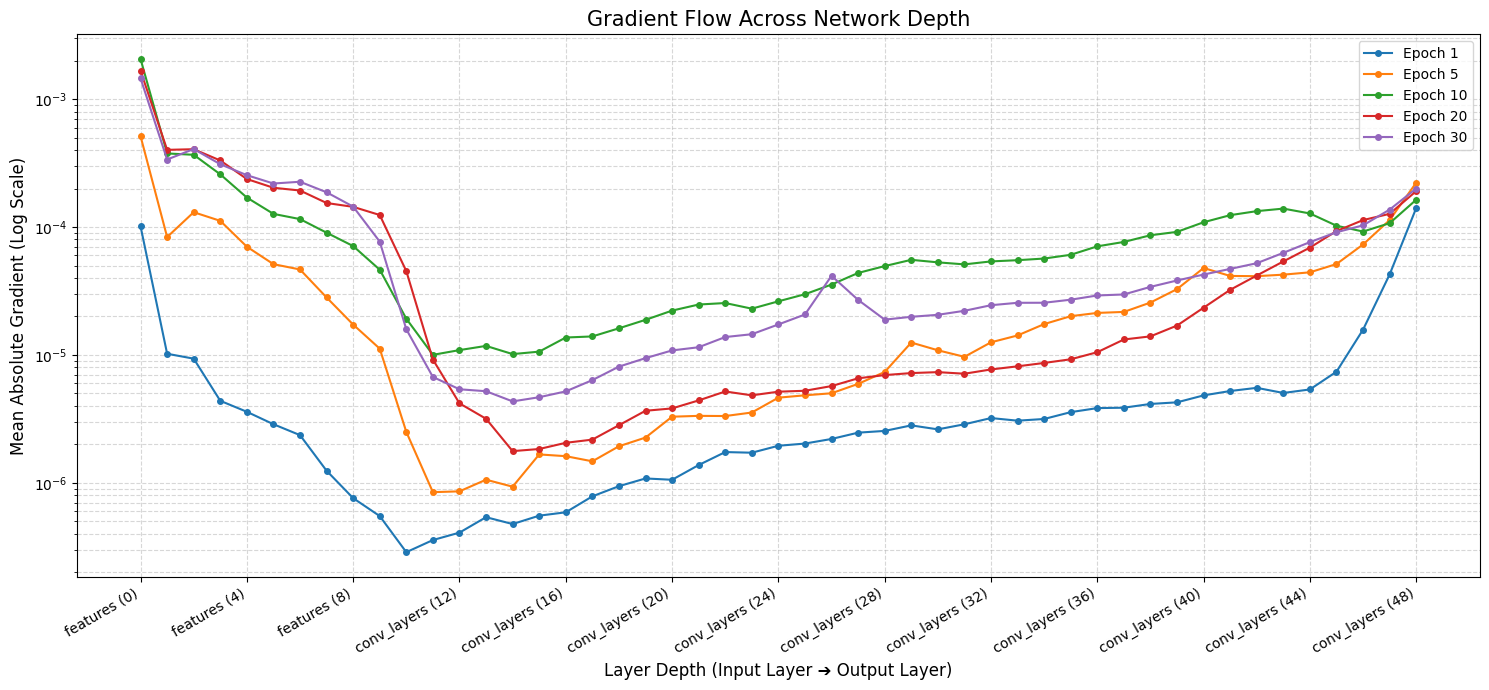

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 레이어 이름 리스트 (선언된 순서대로 정렬되어 있습니다)
layer_names = list(grad_logs_VGG.keys())
num_layers = len(layer_names)

plt.figure(figsize=(15, 7))

# 2. 비교해보고 싶은 주요 에폭(Epoch)들 선택 (0-indexed 인덱스)
# 30에폭 중 초반, 중반, 마지막 흐름을 보기 위해 골랐습니다.
epochs_to_show = [0, 4, 9, 19, EPOCHS - 1] 

for ep in epochs_to_show:
    grads_at_epoch = [grad_logs_VGG[name][ep] for name in layer_names]
    plt.plot(range(num_layers), grads_at_epoch, marker='o', markersize=4, label=f'Epoch {ep + 1}')

plt.title("Gradient Flow Across Network Depth", fontsize=15)
plt.xlabel("Layer Depth (Input Layer ➔ Output Layer)", fontsize=12)
plt.ylabel("Mean Absolute Gradient (Log Scale)", fontsize=12)
plt.yscale('log')

# 3. X축 레이블 가독성 높이기
step = max(1, num_layers // 10)
tick_indices = range(0, num_layers, step)
tick_labels = [layer_names[i].split('.')[0] + f' ({i})' for i in tick_indices]

plt.xticks(tick_indices, tick_labels, rotation=30, ha='right')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

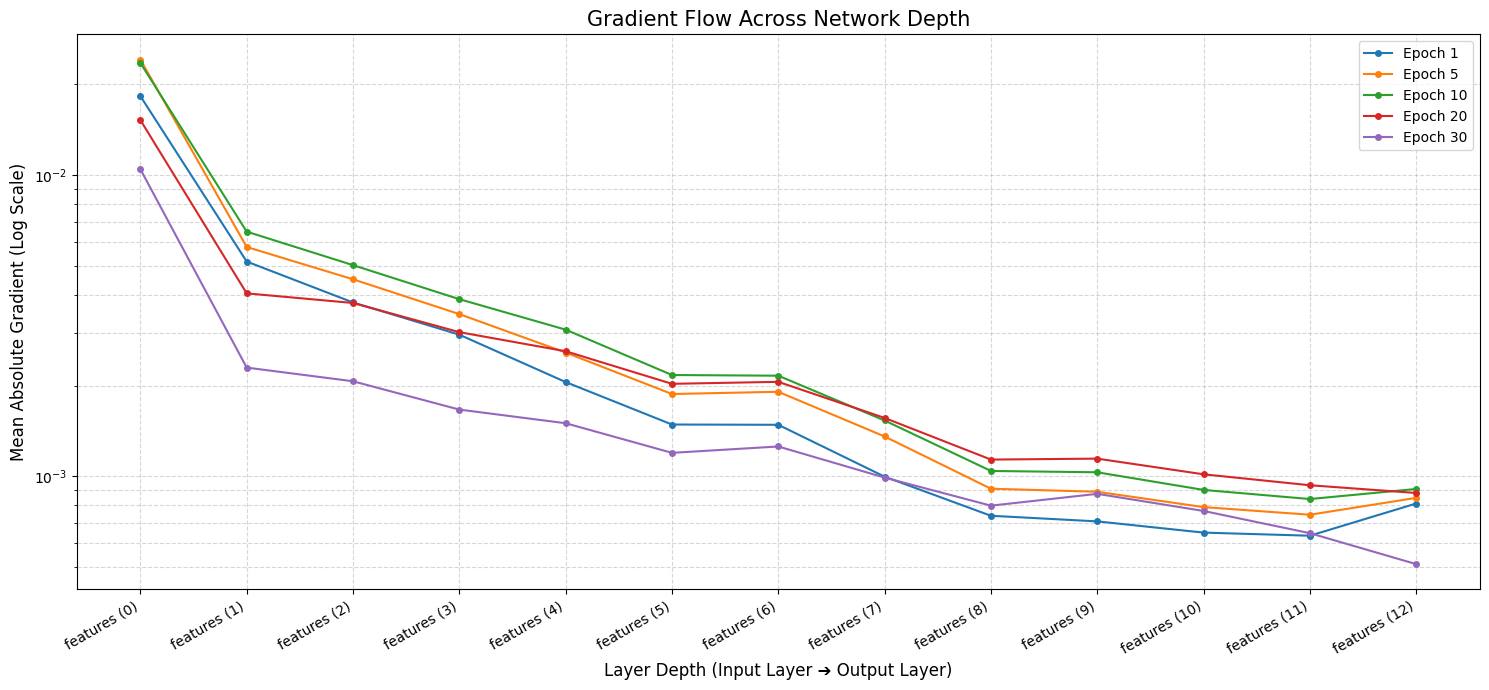

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 레이어 이름 리스트 (선언된 순서대로 정렬되어 있습니다)
layer_names = list(grad_logs_VGG_baseline.keys())
num_layers = len(layer_names)

plt.figure(figsize=(15, 7))

# 2. 비교해보고 싶은 주요 에폭(Epoch)들 선택 (0-indexed 인덱스)
# 30에폭 중 초반, 중반, 마지막 흐름을 보기 위해 골랐습니다.
epochs_to_show = [0, 4, 9, 19, EPOCHS - 1] 

for ep in epochs_to_show:
    grads_at_epoch = [grad_logs_VGG_baseline[name][ep] for name in layer_names]
    plt.plot(range(num_layers), grads_at_epoch, marker='o', markersize=4, label=f'Epoch {ep + 1}')

plt.title("Gradient Flow Across Network Depth", fontsize=15)
plt.xlabel("Layer Depth (Input Layer ➔ Output Layer)", fontsize=12)
plt.ylabel("Mean Absolute Gradient (Log Scale)", fontsize=12)
plt.yscale('log')

# 3. X축 레이블 가독성 높이기
step = max(1, num_layers // 10)
tick_indices = range(0, num_layers, step)
tick_labels = [layer_names[i].split('.')[0] + f' ({i})' for i in tick_indices]

plt.xticks(tick_indices, tick_labels, rotation=30, ha='right')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

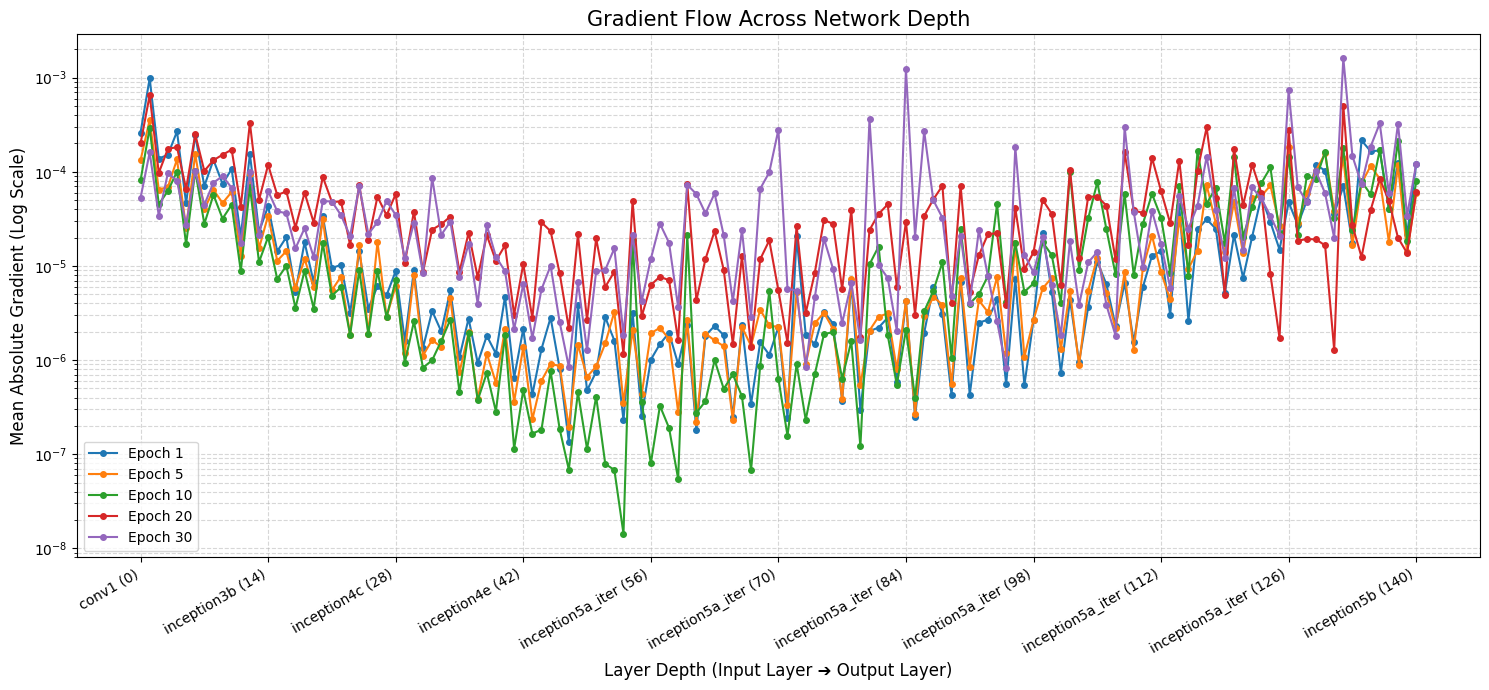

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 레이어 이름 리스트 (선언된 순서대로 정렬되어 있습니다)
layer_names = list(grad_logs_GoogLeNet.keys())
num_layers = len(layer_names)

plt.figure(figsize=(15, 7))

# 2. 비교해보고 싶은 주요 에폭(Epoch)들 선택 (0-indexed 인덱스)
# 30에폭 중 초반, 중반, 마지막 흐름을 보기 위해 골랐습니다.
epochs_to_show = [0, 4, 9, 19, EPOCHS - 1] 

for ep in epochs_to_show:
    grads_at_epoch = [grad_logs_GoogLeNet[name][ep] for name in layer_names]
    plt.plot(range(num_layers), grads_at_epoch, marker='o', markersize=4, label=f'Epoch {ep + 1}')

plt.title("Gradient Flow Across Network Depth", fontsize=15)
plt.xlabel("Layer Depth (Input Layer ➔ Output Layer)", fontsize=12)
plt.ylabel("Mean Absolute Gradient (Log Scale)", fontsize=12)
plt.yscale('log')

# 3. X축 레이블 가독성 높이기
step = max(1, num_layers // 10)
tick_indices = range(0, num_layers, step)
tick_labels = [layer_names[i].split('.')[0] + f' ({i})' for i in tick_indices]

plt.xticks(tick_indices, tick_labels, rotation=30, ha='right')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

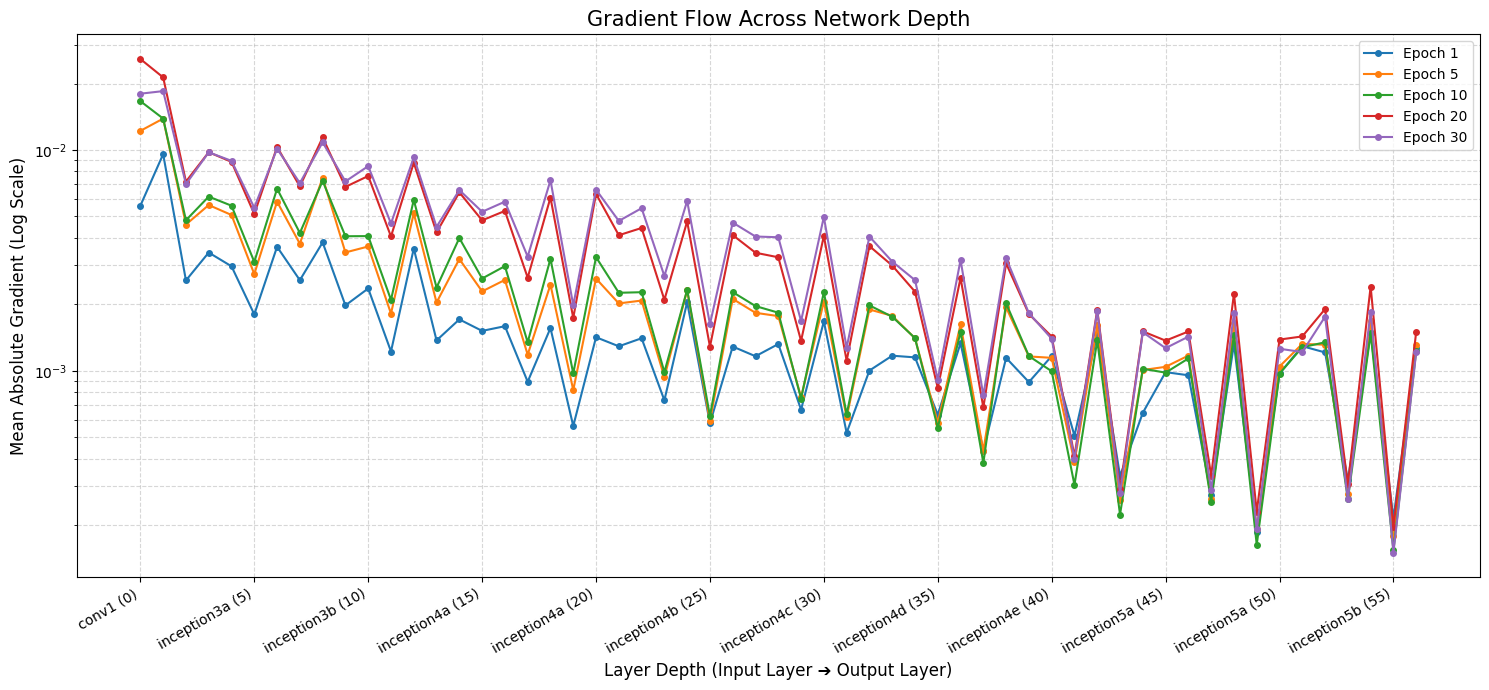

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 레이어 이름 리스트 (선언된 순서대로 정렬되어 있습니다)
layer_names = list(grad_logs_GoogLeNet_baseline.keys())
num_layers = len(layer_names)

plt.figure(figsize=(15, 7))

# 2. 비교해보고 싶은 주요 에폭(Epoch)들 선택 (0-indexed 인덱스)
# 30에폭 중 초반, 중반, 마지막 흐름을 보기 위해 골랐습니다.
epochs_to_show = [0, 4, 9, 19, EPOCHS - 1] 

for ep in epochs_to_show:
    grads_at_epoch = [grad_logs_GoogLeNet_baseline[name][ep] for name in layer_names]
    plt.plot(range(num_layers), grads_at_epoch, marker='o', markersize=4, label=f'Epoch {ep + 1}')

plt.title("Gradient Flow Across Network Depth", fontsize=15)
plt.xlabel("Layer Depth (Input Layer ➔ Output Layer)", fontsize=12)
plt.ylabel("Mean Absolute Gradient (Log Scale)", fontsize=12)
plt.yscale('log')

# 3. X축 레이블 가독성 높이기
step = max(1, num_layers // 10)
tick_indices = range(0, num_layers, step)
tick_labels = [layer_names[i].split('.')[0] + f' ({i})' for i in tick_indices]

plt.xticks(tick_indices, tick_labels, rotation=30, ha='right')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

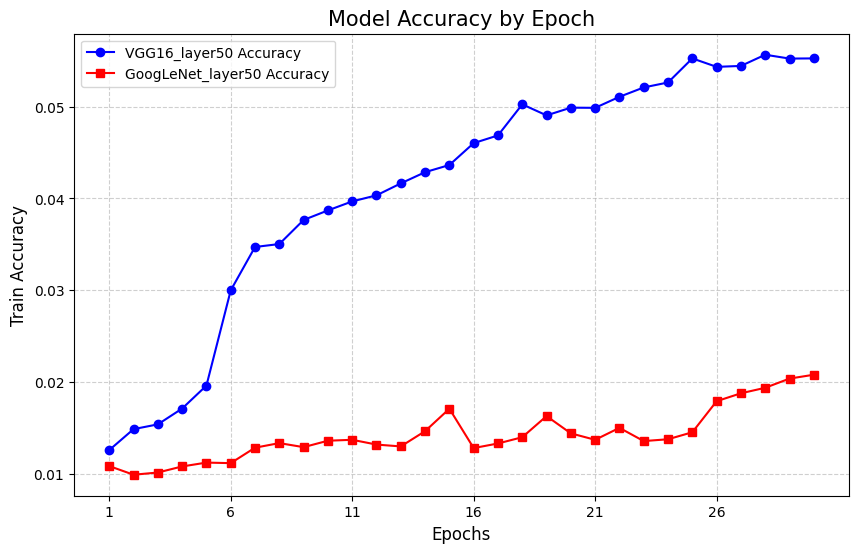

In [21]:
import matplotlib.pyplot as plt

# epoch별 모델 정확도 시각화
plt.figure(figsize=(10, 6))
epochs = range(1, EPOCHS + 1)

plt.plot(epochs, train_logs["VGG16_layer50_acc"], 'b-o', label='VGG16_layer50 Accuracy')
plt.plot(epochs, train_logs["GoogLeNet_layer50_acc"], 'r-s', label='GoogLeNet_layer50 Accuracy')
plt.xticks(range(1, EPOCHS + 1, 5))

plt.title(f'Model Accuracy by Epoch', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Train Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

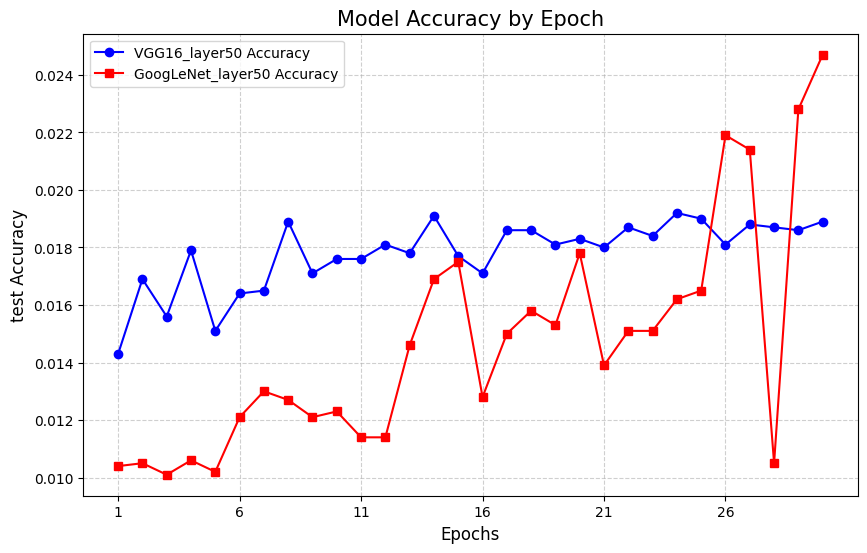

In [22]:
import matplotlib.pyplot as plt

# epoch별 모델 정확도 시각화
plt.figure(figsize=(10, 6))
epochs = range(1, EPOCHS + 1)

plt.plot(epochs, test_logs["VGG16_layer50_acc"], 'b-o', label='VGG16_layer50 Accuracy')
plt.plot(epochs, test_logs["GoogLeNet_layer50_acc"], 'r-s', label='GoogLeNet_layer50 Accuracy')
plt.xticks(range(1, EPOCHS + 1, 5))

plt.title(f'Model Accuracy by Epoch', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('test Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

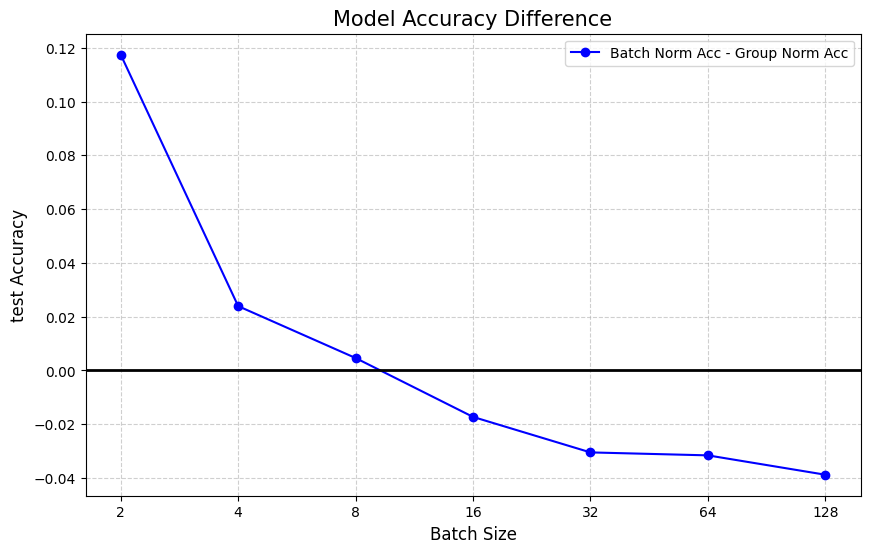

In [ ]:
import matplotlib.pyplot as plt

# batch size별 정확도 얼마나 차이나는지 시각화
plt.figure(figsize=(10, 6))
batchsize__ = [2, 4, 8, 16, 32, 64, 128]


bn_acc = batchsize_test_logs["batch_norm_acc"][::-1]
gn_acc = batchsize_test_logs["group_norm_acc"][::-1]
diff_acc = [gn - bn for gn, bn in zip(gn_acc, bn_acc)]

plt.plot(batchsize__, diff_acc, 'b-o', label='Batch Norm Acc - Group Norm Acc')
plt.xscale('log', base=2)
plt.xticks(batchsize__, labels=batchsize__)

plt.title(f'Model Accuracy Difference', fontsize=15)
plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('test Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=2, linestyle='-')
plt.show()